# Purpose of the Code

The goal of this notebook is to extract the Maximum Voluntary Contraction (MVC) value from EMG signal recorded from a specific muscle using Myo system. The code processes the raw EMG data, identifies the segment corresponding to the peak muscle activation, and computes the maximum amplitude.

## Environment Setup

In [1]:
# pip install libemg  # Required only if you have never installed the libemg package
# pip install --upgrade paramiko cryptography  # Needed during first-time installation of libemg to resolve dependencies

In [2]:
import os
import pandas as pd
import numpy as np
import sys
sys.path.append('../../lib')
from import_file import import_data_from_myo
from myo_utils import myo_dataframe_edit, myo_extract_muscle_emg, myo_extract_imu
from emg_utils import plot_emg_signal, emg_filters, compute_MVC
from imu_utils import imu_lowpass_filt

In [3]:
# Parameters
subj = "01"
date = "07_30"
folder = "_mvc"
cutoff_imu = 5 # Frequency for low-pass IMU filter
channel_numbers = [1,2,3,4,5,6,7,8]  # Possible channels: from 1 to 8
channel_names = [f"channel_{num}" for num in channel_numbers] # Create channel of interest names
smooth_threshold_myo = 3

fs = 200 # Frequency of Myo armband
fs_list = []  # Initialize list to store sampling frequencies
mvc_dict = {}

# Paths for input and output
#input_folder = f'../../data/acquisitions/myo/{date}/S{subj}/{folder}/'  # Input folder with raw data
input_folder = f'../../data/acquisitions/myo/{date}/{folder}/'
full_path = os.path.join(f'../../data/mvc_values/myo/S{subj}_{date}/', f'S{subj}.csv') # output folder and file name
full_path_2 = os.path.join(f'../../data/mvc_values/myo/S{subj}_{date}/', f'imu_scalers.pkl') # output folder and file name

# Loading Data Files

In [4]:
dataframes = import_data_from_myo(input_folder)  # Import raw data from Myo folder
dataframes = [myo_dataframe_edit(df) for df in dataframes]  # Format each imported dataframe

In [5]:
muscle_emg_raw, emg_time = myo_extract_muscle_emg(dataframes, channel_names, fs)  # Extract EMG signals and timestamps for the specified channels

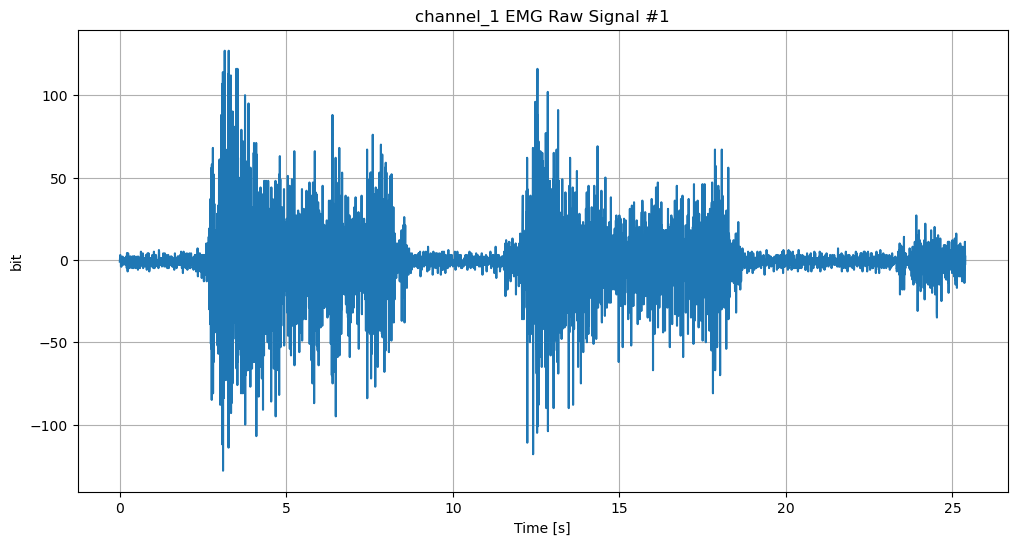

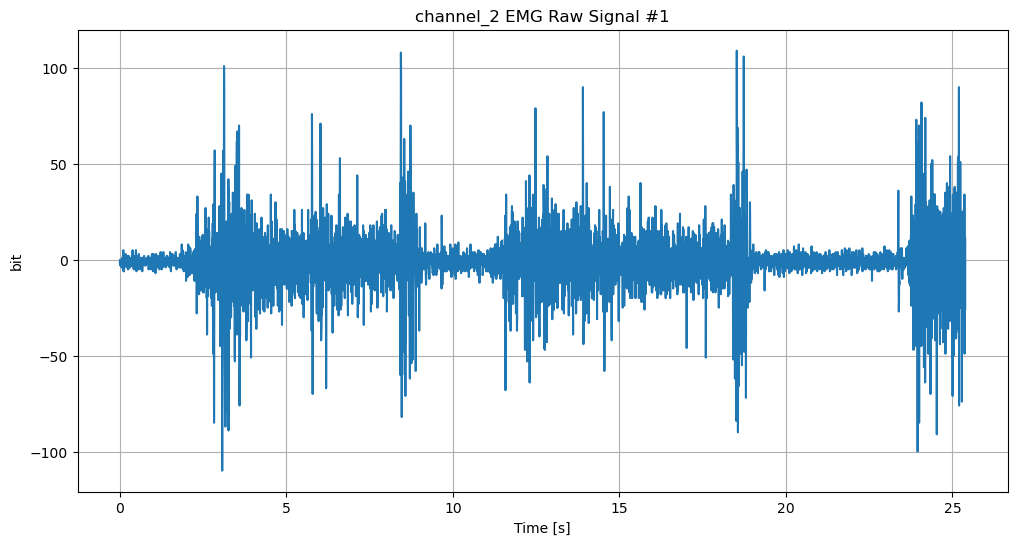

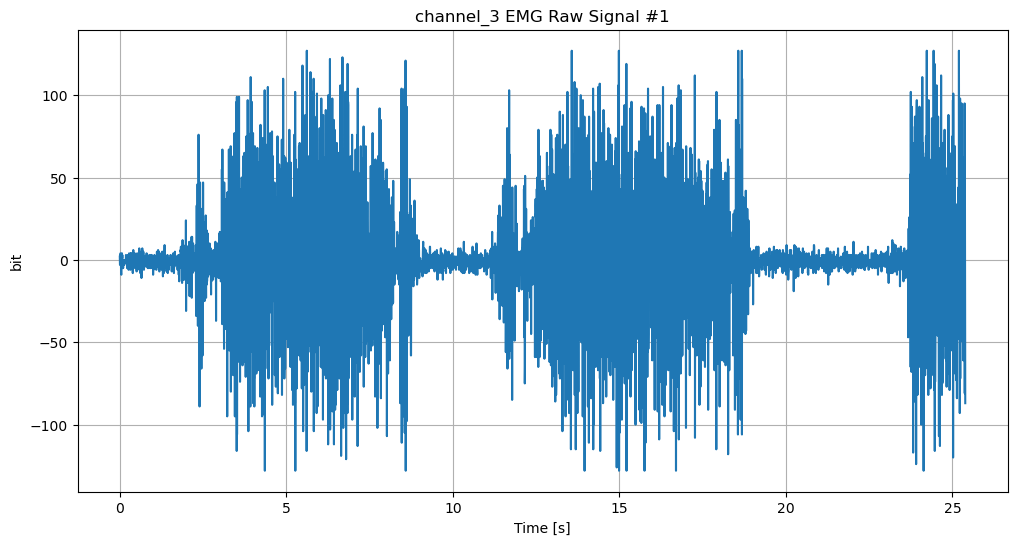

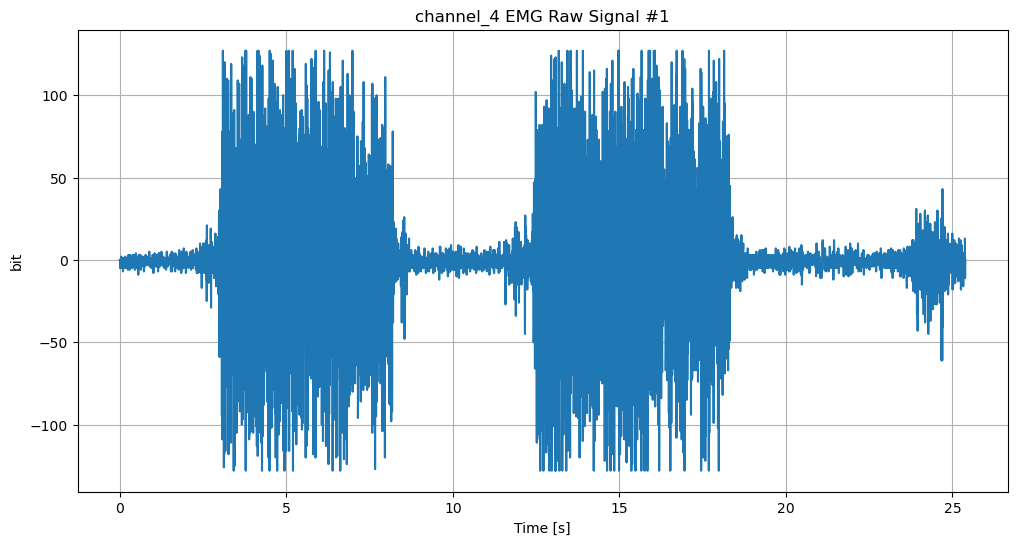

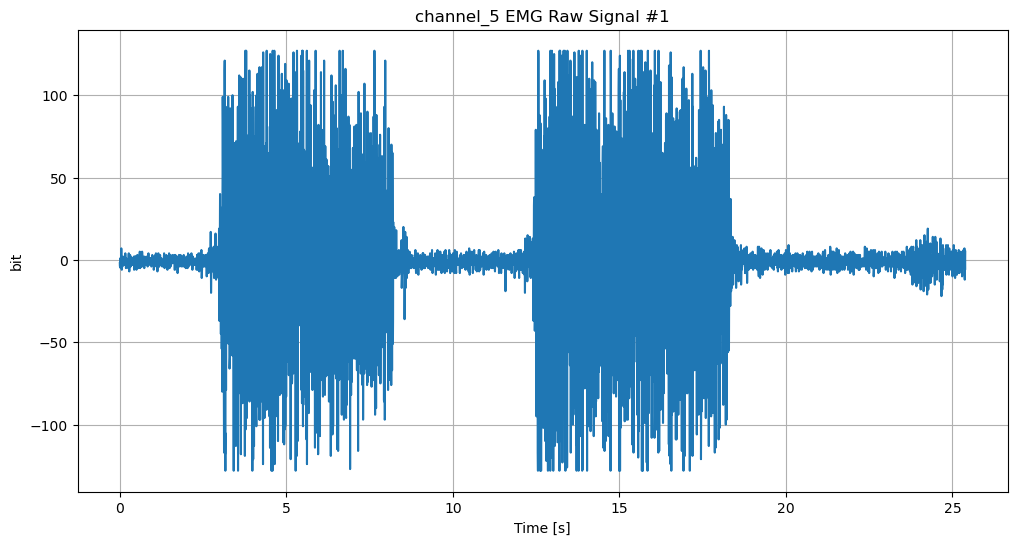

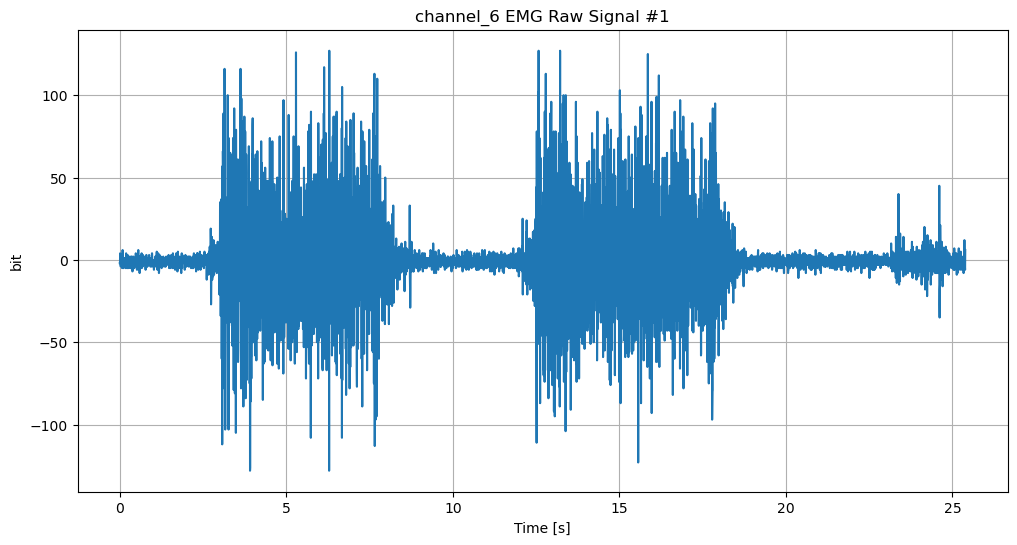

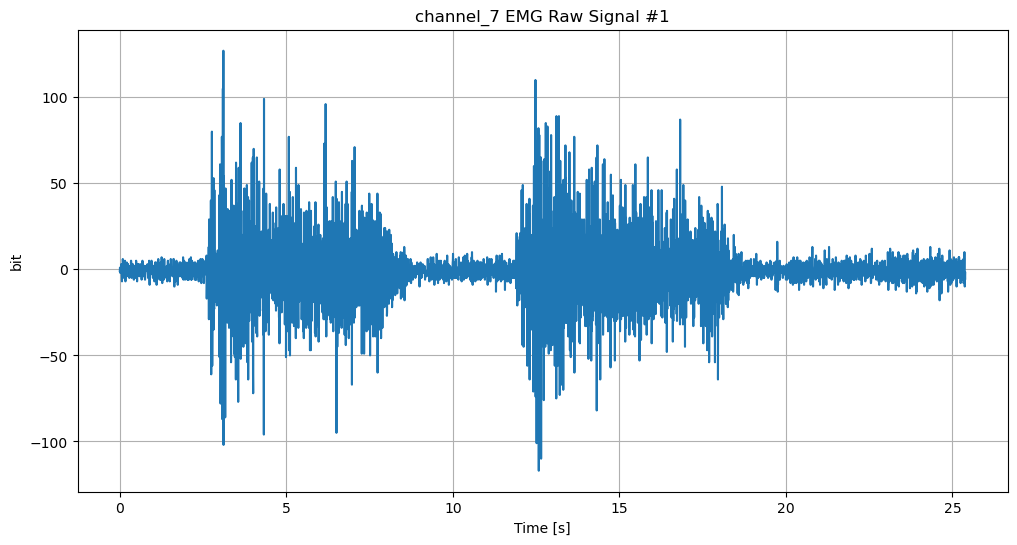

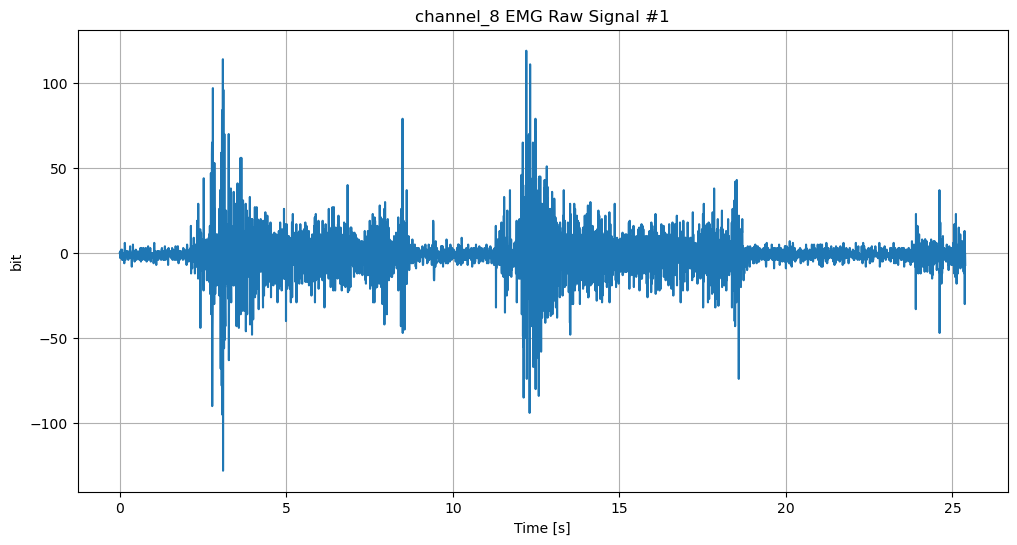

In [6]:
for channel in channel_names:
    plot_emg_signal(muscle_emg_raw[channel][0], emg_time[0], title=f"{channel} EMG Raw Signal #1", ylabel="bit")  # Plot raw EMG signal

# EMG Signal Analysis

## Filtering, Rectification, Smoothing and Normalization

In [7]:
for time in emg_time:
    fs_list.append(fs)

In [8]:
_, _, muscle_emg_smoothed = emg_filters(muscle_emg_raw, emg_time, fs_list)

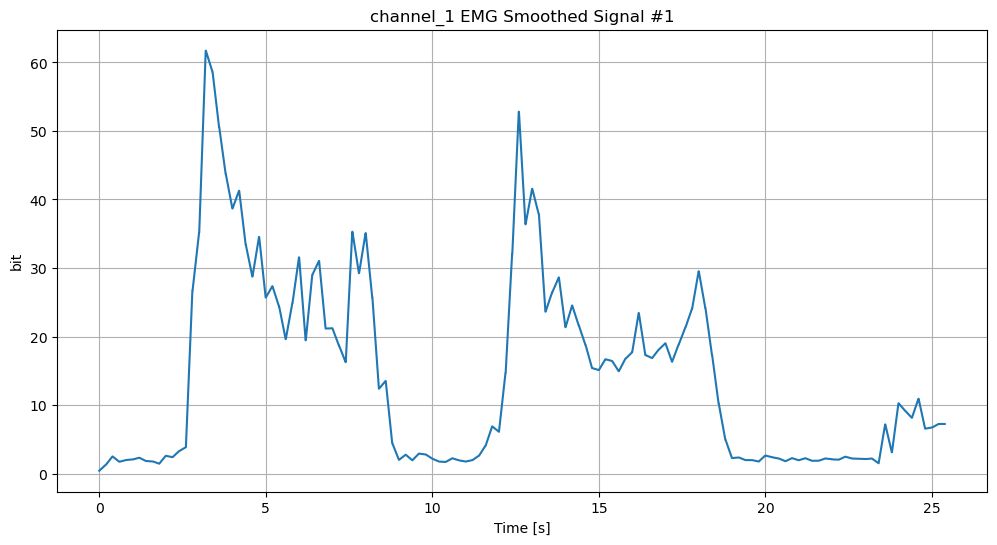

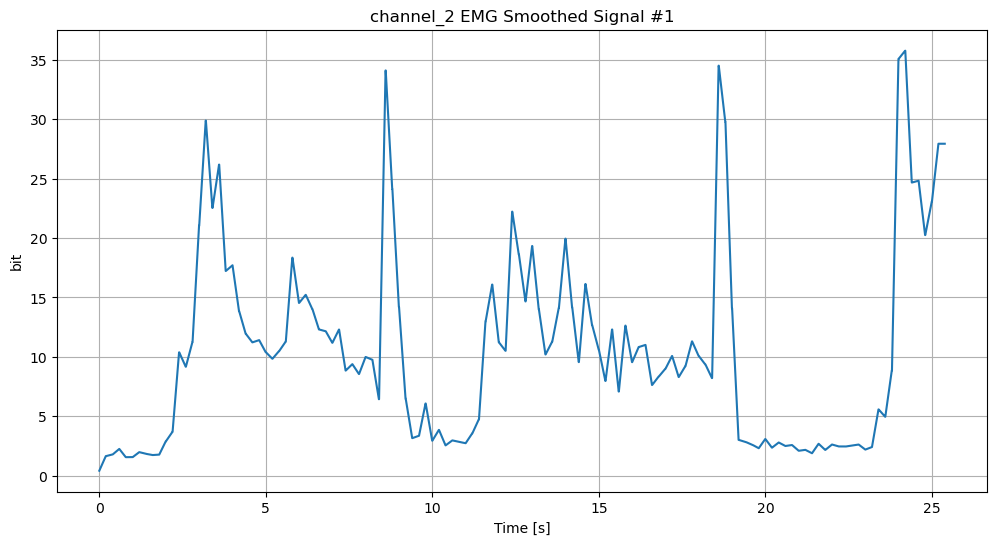

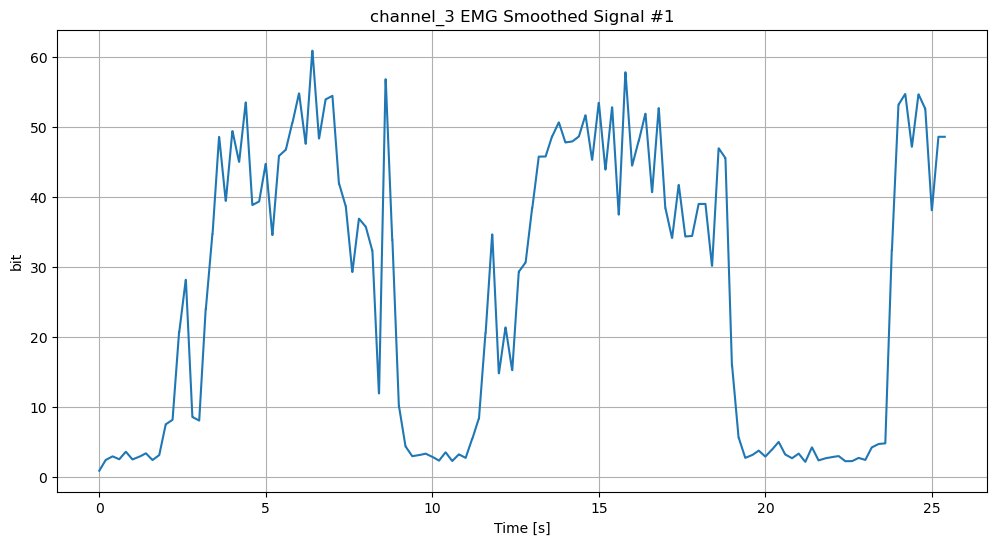

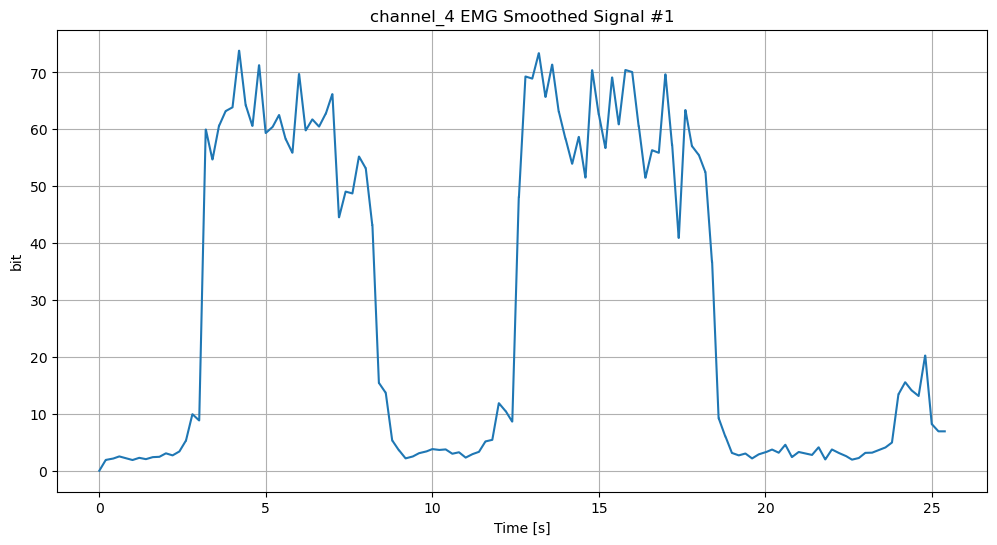

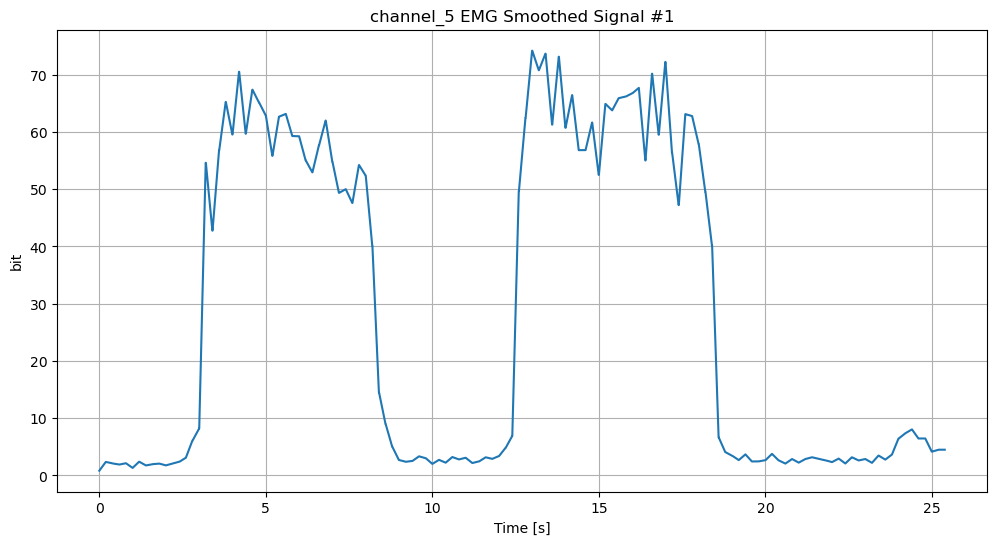

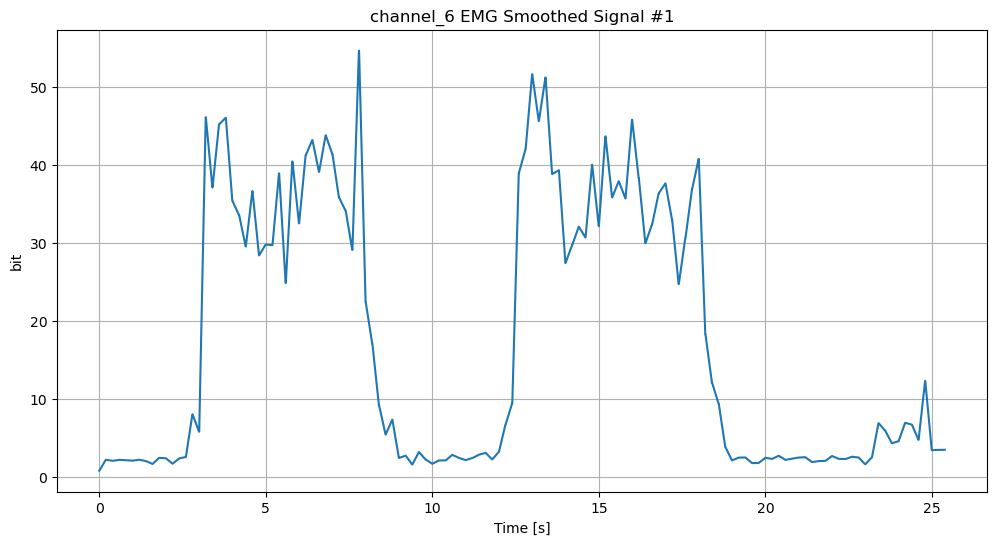

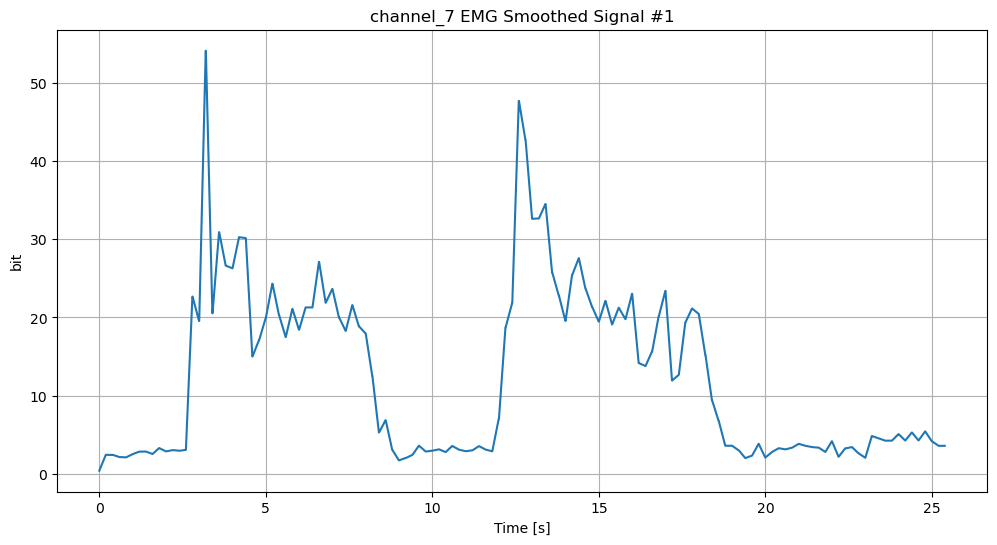

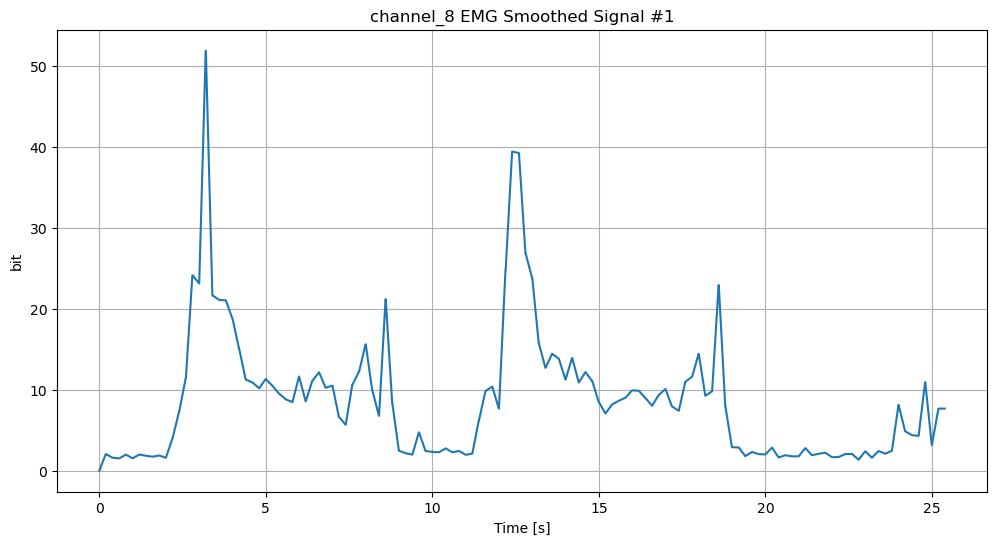

In [9]:
for channel in channel_names:
    plot_emg_signal(muscle_emg_smoothed[channel][0], emg_time[0], 
                    title=f"{channel} EMG Smoothed Signal #1", ylabel="bit")  # Plot normalized EMG signal

# Compute MVC

In [12]:
for channel in channel_names:
    signal = muscle_emg_smoothed[channel][0]
    mvc = compute_MVC(signal, fs, window=0.05, smooth_threshold=smooth_threshold_myo)
    mvc = max(signal)
    mvc_dict[channel] = mvc

# Export MVC

In [13]:
mvc_df = pd.DataFrame.from_dict(mvc_dict, orient='index', columns=['MVC'])
print(mvc_df)

                 MVC
channel_1  61.703726
channel_2  35.776840
channel_3  60.919703
channel_4  73.822442
channel_5  74.179239
channel_6  54.643682
channel_7  54.079109
channel_8  51.879772


In [14]:
mvc_df.to_csv(full_path)

# IMU Scaler

In [13]:
imu_myo, imu_time_myo, fs_imu_list_myo = myo_extract_imu(dataframes) 

In [14]:
for i in range(len(imu_time_myo)):
    fs_myo = fs_imu_list_myo[i] # Sampling frequency per trial

In [15]:
from sklearn.preprocessing import MinMaxScaler
imu_processed = {}
imu_scalers = {}  # dizionario per salvare uno scaler per ogni channel
scale_range=(-1, 1)

for channel in list(imu_myo.keys())[:6]: # iteri sulle chiavi del dizionario
    imu_processed[channel] = {}

    all_filtered_segments = []
    segment_lengths = []
    
    time = imu_time_myo[0]
    raw_data = imu_myo[channel][0]

    if np.any(np.isnan(raw_data)):
        nans = np.isnan(raw_data)
        not_nans = ~nans                
        raw_data[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(not_nans), raw_data[not_nans])

    fs = 1 / np.mean(np.diff(time))
    filtered = imu_lowpass_filt(raw_data, cutoff=cutoff_imu, fs=fs)
    all_filtered_segments.append(filtered.reshape(-1, 1))
    segment_lengths.append(len(filtered))


    all_filtered_concat = np.vstack(all_filtered_segments)
    scaler = MinMaxScaler(feature_range=scale_range)
    all_scaled_concat = scaler.fit_transform(all_filtered_concat)
    imu_scalers[channel] = scaler

In [16]:
print (imu_scalers)

{'ACC_X': MinMaxScaler(feature_range=(-1, 1)), 'ACC_Y': MinMaxScaler(feature_range=(-1, 1)), 'ACC_Z': MinMaxScaler(feature_range=(-1, 1)), 'GYR_X': MinMaxScaler(feature_range=(-1, 1)), 'GYR_Y': MinMaxScaler(feature_range=(-1, 1)), 'GYR_Z': MinMaxScaler(feature_range=(-1, 1))}


In [17]:
import joblib

joblib.dump(imu_scalers, full_path_2)

['../../data/mvc_values/myo/S01_07_24/imu_scalers.pkl']